Importación de los módulos a usar en el taller

In [12]:
import os
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, HalvingGridSearchCV, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB

# 1. Exploración del dataset

El dataset original fue creado con el propósito de hacer clasificación de texto jerarquíca, para lo cual se dispone de reseñas de productos de Amazon con 3 niveles de categorías. Sin embargo, en este taller solo nos ocuparemos de asignar a cada reseña la categoría de primer nivel (hay 6 categorías de primer nivel).

El dataset puede descargarse directamente en [Kaggle](https://www.kaggle.com/datasets/kashnitsky/hierarchical-text-classification), pero en el entorno de ejecución del taller ya se encuentra descargado el dataset, que consiste de un archivo tipo csv para entrenamiento con 40 mil reseñas, y un archivo de evaluación con 10 mil reseñas.

In [13]:
# Cargar los datos de entrenamiento en un DataFrame
df_train = pd.read_csv('data/train_40k.csv')

Veamos la información disponible para los primeros datos del dataset:

In [14]:
df_train.head()

,productId,Title,userId,Helpfulness,Score,Time,Text,Cat1,Cat2,Cat3
0,B000E46LYG,Golden Valley Natural Buffalo Jerky,A3MQDNGHDJU4MK,0/0,3.0,-1,The description and photo on this product need...,grocery gourmet food,meat poultry,jerky
1,B000GRA6N8,Westing Game,unknown,0/0,5.0,860630400,This was a great book!!!! It is well thought t...,toys games,games,unknown
2,B000GRA6N8,Westing Game,unknown,0/0,5.0,883008000,"I am a first year teacher, teaching 5th grade....",toys games,games,unknown
3,B000GRA6N8,Westing Game,unknown,0/0,5.0,897696000,I got the book at my bookfair at school lookin...,toys games,games,unknown
4,B00000DMDQ,I SPY A is For Jigsaw Puzzle 63pc,unknown,2/4,5.0,911865600,Hi! I'm Martine Redman and I created this puzz...,toys games,puzzles,jigsaw puzzles


Calculemos cuántas reseñas hay por cada una de las categorías:

In [15]:
df_train.groupby('Cat1').size()

Cat1
baby products            5637
beauty                   5846
grocery gourmet food     3617
health personal care     9772
pet supplies             4862
toys games              10266
dtype: int64

Como se observa, el dataset no está balanceado y las categorías de **toys games** y **health personal care** tienen la mayor cantidad de reseñas.

Ahora veamos estadísticas descriptivas sobre **Title** y **Text** que serán las características que usaremos para constuir el clasificador:

In [16]:
df_train[["Title", "Text"]].describe()

,Title,Text
count,39984,40000
unique,19597,39489
top,Pampers Baby Dry Diapers (Packaging May Vary),Length:
freq,282,28


Encontramos que hay 16 títulos faltantes en las reseñas. También se observa la presencia de datos repetidos principalmente en los títulos pero también en el texto de las reseñas.

## 1.1. Ejercicio 1: Limpieza de datos

Complete el cuerpo de la función `clean_data` con los siguientes objetivos:
* Eliminar las filas de datos que contienen faltantes en **Title**.
* Eliminar los datos duplicados en la característica de **Text**.

**Importante**: No remover las filas con datos nulos de otras columnas que no sea **Title**, y tampoco remover duplicados de otras columnas que no sea **Text**. Por último, debe retornar un DataFrame con todas las columnas del DataFrame de entrada.

In [17]:
def clean_data(train_data: pd.DataFrame) -> pd.DataFrame:
    """
    Limpia los datos de entrenamiento. Elimina las filas con valores nulos , y los duplicados en la característica "Text".

    Args:
        train_data (pd.DataFrame): DataFrame con los datos de entrenamiento.

    Returns:
        pd.DataFrame: DataFrame con los datos limpios.
    """
    # Complete el cuerpo de función guíandose por la documentación de la función provista
    ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
    # your code here
    data_clean = train_data.drop_duplicates(subset=['Text'])
    data_clean = data_clean.dropna(subset=['Title'])
    return data_clean
    #raise NotImplementedError
    ## FIN DE IMPLEMENTACIÓN (NO MODIFICAR DESPUÉS ESTA LÍNEA)

# Pruebe su implementación
df_train = clean_data(df_train)
df_train[["Title", "Text"]].describe()

,Title,Text
count,39473,39473
unique,19567,39473
top,Pampers Baby Dry Diapers (Packaging May Vary),The description and photo on this product need...
freq,268,1


Observe el contenido de las características que usaremos para constuir el clasificador del primer dato del set de entrenamiento:

In [18]:
# Puede cambiar el id para explorar otros datos
df_train.iloc[0]['Title'], df_train.iloc[0]['Text']

('Golden Valley Natural Buffalo Jerky',
 'The description and photo on this product needs to be changed to indicate this product is the BuffalOs version of this beef jerky.')

Ahora creemos una función de utilidad sencilla para concatenar el título con el texto, y para definir la etiqueta de los datos:

In [19]:
def pre_process_text(data: pd.DataFrame) -> tuple:
    """
    Preprocesa el texto para poder ser utilizado en un modelo de clasificación.

    Args:
        data (DataFrame): DataFrame con los datos a preprocesar.

    Returns:
        (tuple): Tupla con los datos preprocesados.
    """
    X = data['Title'] + '. ' + data['Text']
    y = data['Cat1']

    return X.values, y.values

X_train, y_train = pre_process_text(df_train)
print(X_train.shape, y_train.shape)

(39473,) (39473,)


# 2. Seleccionar la representación textual

En esta sección, vamos a evaluar distintas representaciones textuales para encontrar aquella que mejor se ajuste a la tarea de clasificación.

## 2.1. Ejercicio 2: Selección de la representación textual

En este ejercicio usted debe definir el espacio de búsqueda para ser utilizado por la técnica [HalvingGridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.HalvingGridSearchCV.html#sklearn.model_selection.HalvingGridSearchCV) de **scikit-learn**, en el cual se deben evaluar por lo menos CountVectorizer y TfidfVectorizer, en al menos un modelo de clasificación. Adicionalmente se deben evaluar por lo menos dos hiperparámetros diferentes de los vectorizadores.

**Nota**: Se recomienda hacer un máximo de 2 rondas de validación cruzada, y utilizar como clasificador un Regresor Logístico para reducir los tiempos de entrenamiento. Adicionalmente, se sugiere usar `n_jobs=os.cpu_count()`, y probar solo 2 valores para los dos hiperparámetros a ajustar.

In [20]:
def create_search_grid() -> HalvingGridSearchCV:
    """
    Crea un objeto tipo HalvingGridSearchCV con los parámetros a evaluar.
    El pipeline debe contener los siguientes pasos:
        - representation.
        - classifier.
    Para el paso de representation se deben evaluar por los menos los vectorizadores CountVectorizer y TfidfVectorizer, y se deben evaluar por lo menos dos
    hiperparámetros de los mismos.
    Se debe utilizar la métrica f1_macro para evaluar el desempeño de los modelos (defínala como un string para que los tests funcionen correctamente).

    Returns:
        (HalvingGridSearchCV) Objeto con el espacio de búsqueda definido.

    Examples:
    >>> search = create_search_grid()
    >>> print(search)
    HalvingGridSearchCV() # Dentro de los paréntesis se mostrarán los parámetros definidos.
    """
    # Complete el cuerpo de función guíandose por la documentación de la función provista
    ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
    # your code here
    # Definimos la secuencia de pasos del pipeline que en este caso consiste en un vectorizador y un clasificador
    pipeline = Pipeline([
        ('representation', CountVectorizer()),
        ('classifier', LogisticRegression())
    ])

    param_grid = [
        {
            'representation': [CountVectorizer(), TfidfVectorizer()],
            'representation__max_df': [0.8, 1.0],
            'representation__min_df': [1, 5],
            'classifier': [LogisticRegression(max_iter=1000)],
        }
    ]
    search =  HalvingGridSearchCV(pipeline, param_grid, cv=2, scoring='f1_macro', n_jobs=os.cpu_count())
    
    return search
    
    #raise NotImplementedError
    ## FIN DE IMPLEMENTACIÓN (NO MODIFICAR DESPUÉS ESTA LÍNEA)

search = create_search_grid()
print(search)

HalvingGridSearchCV(cv=2,
                    estimator=Pipeline(steps=[('representation',
                                               CountVectorizer()),
                                              ('classifier',
                                               LogisticRegression())]),
                    n_jobs=64,
                    param_grid=[{'classifier': [LogisticRegression(max_iter=1000)],
                                 'representation': [CountVectorizer(),
                                                    TfidfVectorizer()],
                                 'representation__max_df': [0.8, 1.0],
                                 'representation__min_df': [1, 5]}],
                    scoring='f1_macro')


Realicemos el entrenamiento de los modelos para encontrar la representación textual con mejor desempeño.

Tener en cuenta que según los parámetros y modelos a evaluar, el entrenamiento puede tardar una cantidad de tiempo considerable.

In [21]:
search.fit(X_train, y_train)

print("Puntaje del mejor modelo en validación cruzada: {:.2f}".format(search.best_score_))
print("Parámetros del mejor modelo:\n{}\n".format(search.best_params_))

Puntaje del mejor modelo en validación cruzada: 0.89
Parámetros del mejor modelo:
{'classifier': LogisticRegression(max_iter=1000), 'representation': TfidfVectorizer(), 'representation__max_df': 1.0, 'representation__min_df': 1}



Revise los parámetros de las 20 mejores configuraciones y los resultados obtenidos. Tenga en cuenta que puede ver varios resultados con el mismo modelo debido a que HalvingGridSearchCV realiza varias iteraciones. En cada iteración se utilizan más datos para entrenar los candidatos y solo pasan a la siguiente iteración los cadidatos con mejor desempeño.

In [22]:
df_results = pd.DataFrame(search.cv_results_)
df_results = df_results.sort_values(by='rank_test_score')
df_results.head(20)

,iter,n_resources,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier,param_representation,param_representation__max_df,param_representation__min_df,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,mean_train_score,std_train_score
8,1,39471,10.220641,0.151520,1.673112,0.092580,LogisticRegression(max_iter=1000),TfidfVectorizer(),1.0,1,{'classifier': LogisticRegression(max_iter=100...,0.906044,0.883801,0.894922,0.011121,1,0.955506,0.961859,0.958683,0.003176
9,1,39471,6.012147,0.073423,1.675438,0.012836,LogisticRegression(max_iter=1000),TfidfVectorizer(),0.8,5,{'classifier': LogisticRegression(max_iter=100...,0.906020,0.883703,0.894862,0.011158,2,0.953039,0.959015,0.956027,0.002988
10,1,39471,11.176897,0.410577,1.657332,0.039494,LogisticRegression(max_iter=1000),TfidfVectorizer(),0.8,1,{'classifier': LogisticRegression(max_iter=100...,0.906461,0.882674,0.894568,0.011893,3,0.955551,0.962468,0.959010,0.003459
4,0,13157,3.663706,0.077654,0.593813,0.025192,LogisticRegression(max_iter=1000),TfidfVectorizer(),0.8,1,{'classifier': LogisticRegression(max_iter=100...,0.867314,0.843491,0.855403,0.011912,4,0.949741,0.960598,0.955169,0.005428
5,0,13157,1.909360,0.025757,0.589490,0.008297,LogisticRegression(max_iter=1000),TfidfVectorizer(),0.8,5,{'classifier': LogisticRegression(max_iter=100...,0.867196,0.842936,0.855066,0.012130,5,0.942630,0.952265,0.947448,0.004817
6,0,13157,4.062478,0.094944,0.566557,0.017020,LogisticRegression(max_iter=1000),TfidfVectorizer(),1.0,1,{'classifier': LogisticRegression(max_iter=100...,0.866627,0.842148,0.854387,0.012240,6,0.949660,0.961047,0.955353,0.005694
2,0,13157,8.543176,0.029388,0.546703,0.033076,LogisticRegression(max_iter=1000),CountVectorizer(),1.0,1,{'classifier': LogisticRegression(max_iter=100...,0.866524,0.841596,0.854060,0.012464,7,1.000000,1.000000,1.000000,0.000000
0,0,13157,7.252962,0.189534,0.558122,0.038480,LogisticRegression(max_iter=1000),CountVectorizer(),0.8,1,{'classifier': LogisticRegression(max_iter=100...,0.866835,0.840982,0.853908,0.012927,8,1.000000,1.000000,1.000000,0.000000
7,0,13157,1.948861,0.046373,0.569345,0.006582,LogisticRegression(max_iter=1000),TfidfVectorizer(),1.0,5,{'classifier': LogisticRegression(max_iter=100...,0.865674,0.840978,0.853326,0.012348,9,0.941019,0.952910,0.946964,0.005945
1,0,13157,3.499815,0.042126,0.556288,0.002444,LogisticRegression(max_iter=1000),CountVectorizer(),0.8,5,{'classifier': LogisticRegression(max_iter=100...,0.860477,0.830183,0.845330,0.015147,10,1.000000,0.999812,0.999906,0.000094


# 3. Selección del clasificador

En La anterior sección ya encontramos una representación textual que parece ajustarse bien a nuestra tarea, ahora debemos seleccionar el modelo de clasificación de texto con mejor desempeño en nuestra tarea particular.

En primer lugar para evaluar distintos modelos de clasificación con la tranquilidad de no realizar un sobre ajuste sobre los datos de entrenamiento, vamos a crear un set de validación sobre el cual podamos comparar distintos modelos de clasificación. Adicionalmente, realizaremos la transformación de los datos con la representación textual seleccionada.

Para el resto del taller usaremos CountVectorizer(max_df=0.5, min_df=1). Sin embargo, si obtuvo resultados mejores con otra representación puede utilizarla.

In [25]:
vectorizer = TfidfVectorizer(max_df=1.0, min_df=1) # Puede cambiar el vectorizador por la representación que haya obtenido mejores resultados en la búsqueda

X_train_vectorized = vectorizer.fit_transform(X_train)
print(X_train_vectorized.shape)

(39473, 53850)


Para seleccionar el modelo vamos a utilizar `GridSearchCV` para probar dos clasificadores distintos:

**Advertencia**: La ejecución de esta celda puede tomar más de 30-40 minutos.

In [26]:
%%time
pipe = Pipeline([('classifier', LogisticRegression(max_iter=1000))])

param_grid = [
    {'classifier': [MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=100)]},
    {'classifier': [LogisticRegression(max_iter=1000)]},
]

search = GridSearchCV(pipe, param_grid, cv=2, verbose=1, n_jobs=os.cpu_count(), scoring='f1_macro')
search.fit(X_train_vectorized, y_train)

print("Puntaje del mejor modelo en validación cruzada: {:.2f}".format(search.best_score_))
print("Parámetros del mejor modelo:\n{}\n".format(search.best_params_))

Fitting 2 folds for each of 2 candidates, totalling 4 fits
Puntaje del mejor modelo en validación cruzada: 0.92
Parámetros del mejor modelo:
{'classifier': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=100)}

CPU times: user 1h 33min 59s, sys: 2h 32min 45s, total: 4h 6min 45s
Wall time: 37min 49s


In [27]:
df_results = pd.DataFrame(search.cv_results_)
df_results.sort_values(by='mean_test_score', ascending=False)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier,params,split0_test_score,split1_test_score,mean_test_score,std_test_score,rank_test_score
0,569.365152,16.400010,0.210266,0.003787,"MLPClassifier(hidden_layer_sizes=(100, 50), ma...",{'classifier': MLPClassifier(hidden_layer_size...,0.929415,0.911506,0.920460,0.008954,1
1,11.721902,0.447506,0.136458,0.014136,LogisticRegression(max_iter=1000),{'classifier': LogisticRegression(max_iter=1000)},0.903520,0.880690,0.892105,0.011415,2


Analice el desempeño obtenido por los diferentes modelos.

# 4. Evaluación del clasificador

En esta sección se realiza la evaluación del clasificador con mejor desempeño según la sección anterior.

## 4.1. Ejercicio 3: Implementación de métrica accuracy

El **accuracy** es una de las métricas más importantes de evaluación para tareas de clasificación. Esta métrica comsiste en calcular la proporción de aciertos de nuestro modelo. Esta métrica es especialmente importante cuando tenemos cantidades similares de datos por clase (dataset balanceado).

In [28]:
def calculate_accuracy(labels: np.array, predictions: np.array) -> float:
    """
    Calcula el accuracy de un modelo de clasificación como la proporción de aciertos.

    Args:
        labels (np.array): Arreglo con las etiquetas reales en donde la etiqueta es una cadena de texto.
        predictions (np.array): Arreglo con las etiquetas predichas en donde la etiqueta es una cadena de texto.

    Returns:
        float: Accuracy del modelo.

    Examples:
    >>> labels = np.array(['a', 'b', 'a', 'a', 'b'])
    >>> predictions = np.array(['a', 'b', 'b', 'a', 'b'])
    >>> accuracy = calculate_accuracy(labels, predictions)
    >>> print(accuracy)
    0.8
    """
    # Complete el cuerpo de la función siguiendo las instrucciones del enunciado
    ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
    # your code here
    aciertos = (labels == predictions)
    accuracy = np.sum(aciertos) / len(labels)
    
    return float(accuracy)    
    
    #raise NotImplementedError
    ## FIN DE IMPLEMENTACIÓN (NO MODIFICAR DESPUÉS DE ESTA LÍNEA)

# Pruebe su implementación
labels = np.array(['a', 'b', 'a', 'a', 'b'])
predictions = np.array(['a', 'b', 'b', 'a', 'b'])
accuracy = calculate_accuracy(labels, predictions)
print(accuracy)

0.8


Para evaluar nuestro modelo debemos cargar los datos de evaluación y procesar los datos de la misma manera que se hizo con los datos de entrenamiento.

In [29]:
# Cargar los datos de evaluación en un DataFrame
df_eval = pd.read_csv('data/val_10k.csv')
df_eval = clean_data(df_eval)

X_test, y_test = pre_process_text(df_eval)
X_test_vectorized = vectorizer.transform(X_test)

X_test_vectorized.shape, y_test.shape

((9849, 53850), (9849,))

Ahora realicemos las predicciones con nuestro clasificador:

In [30]:
y_preds = search.best_estimator_.predict(X_test_vectorized)
y_preds

array(['pet supplies', 'pet supplies', 'beauty', ..., 'pet supplies',
       'pet supplies', 'health personal care'], dtype='<U20')

Utilizando la función calculate_accuracy, evaluemos el desempeño del modelo:

In [31]:
calculate_accuracy(y_test, y_preds)

0.9357295156868718

## 4.2. Ejercicio 4: Implementación de la matriz de confusión

Debido a que el dataset de evaluación no está balanceado, puede ser de mayor utilidad saber los aciertos y equivocaciones de nuestro clasificador para cada una de las clases. Complete el cuerpo de la función `calculate_confusion_matrix` con su implementación de la matriz de confusión.

In [32]:
def calculate_confusion_matrix(y_true: np.array, y_pred: np.array) -> np.array:
    """
    Calcula la matriz de confusión a partir de las etiquetas reales y las predichas.
    En el eje y se deben colocar las etiquetas reales y en el eje x las etiquetas predichas.
    El valor en la posición (i, j) de la matriz de confusión corresponde a la cantidad de instancias que pertenecen a la clase j y fueron clasificadas como i.
    Las clases deben estar ordenadas alfabéticamente, y su función debe considerar todas las clases presentes en las etiquetas reales y predichas.
    Por últimos los datos deben estar normalizados por fila. Es decir, la suma de cada fila debe ser igual a 1.

    Args:
        y_true (np.array): Arreglo con las etiquetas reales en donde la etiqueta es una cadena de texto.
        y_pred (np.array): Arreglo con las etiquetas predichas en donde la etiqueta es una cadena de texto.

    Returns:
        np.array: Matriz de confusión.

    Examples:
    >>> y_true = np.array(['a', 'b', 'a', 'a', 'b'])
    >>> y_pred = np.array(['a', 'b', 'b', 'a', 'b'])
    >>> confusion_matrix = calculate_confusion_matrix(y_true, y_pred)
    >>> print(confusion_matrix)
    array([[0.666..., 0.333...],
           [0, 1]])
    """
    # Complete el cuerpo de la función siguiendo las instrucciones del enunciado
    ## INICIO DE IMPLEMENTACIÓN (ÚNICAMENTE MODIFIQUE EL CÓDIGO AQUÍ)
    # your code here
    classes = np.unique(np.concatenate((y_true, y_pred)))
    n_classes = len(classes)
    cm = np.zeros((n_classes, n_classes))
    class_to_idx = {cls: i for i, cls in enumerate(classes)}
    for actual, predicted in zip(y_true, y_pred):
        i = class_to_idx[actual]    # Eje Y (Real)
        j = class_to_idx[predicted] # Eje X (Predicho)
        cm[i, j] += 1
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_normalized = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)
    return cm_normalized
    
    
    #raise NotImplementedError
    ## FIN DE IMPLEMENTACIÓN (NO MODIFICAR DESPUÉS DE ESTA LÍNEA)

# Pruebe su implementación
sample_labels = np.array(['a', 'b', 'a', 'a', 'b'])
samples_predictions = np.array(['a', 'b', 'b', 'a', 'b'])
confusion_matrix = calculate_confusion_matrix(sample_labels, samples_predictions)
print(confusion_matrix)

[[0.66666667 0.33333333]
 [0.         1.        ]]


Veamos el desempeño del modelo por cada una de las clases:

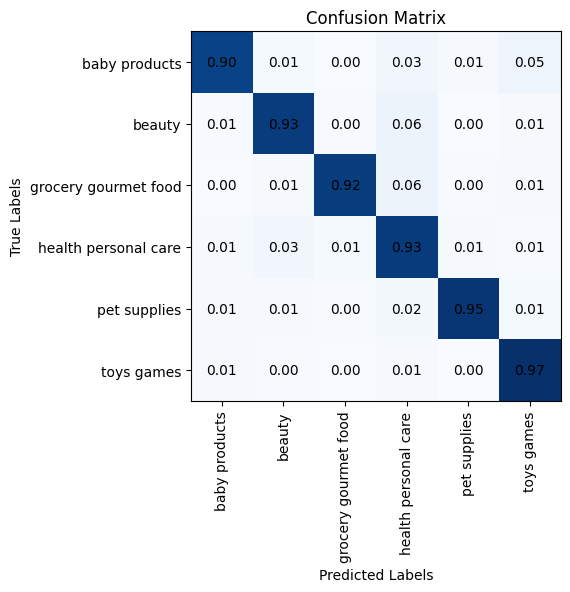

In [33]:
# Calcular la matriz de confusión con la función calculate_confusion_matrix
confusion_matrix = calculate_confusion_matrix(y_test, y_preds)

# Graficar la matriz de confusión
plt.imshow(confusion_matrix, cmap='Blues')

# Añadir los nombres de las clases en los ejes y el título
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(ticks=np.arange(len(search.best_estimator_.classes_)), labels=search.best_estimator_.classes_, rotation=90)
plt.yticks(ticks=np.arange(len(search.best_estimator_.classes_)), labels=search.best_estimator_.classes_)

# Agregar los valores de la matriz de confusión en cada celda
for i in range(confusion_matrix.shape[0]):
    for j in range(confusion_matrix.shape[1]):
        plt.text(j, i, f'{confusion_matrix[i, j]:.2f}', ha='center', va='center', color='black')

Analice el desempeño del modelo para cada una de las clases.

Finalmente, vea el desempeño del modelo frente a otra métricas importantes:

In [34]:
print(classification_report(y_test, y_preds))

                      precision    recall  f1-score   support

       baby products       0.91      0.90      0.90       696
              beauty       0.93      0.93      0.93      2069
grocery gourmet food       0.93      0.92      0.92       832
health personal care       0.92      0.93      0.93      2935
        pet supplies       0.97      0.95      0.96      1564
          toys games       0.95      0.97      0.96      1753

            accuracy                           0.94      9849
           macro avg       0.93      0.93      0.93      9849
        weighted avg       0.94      0.94      0.94      9849



# 5. Conclusiones

Es difícil saber con antelación qué técnicas de procesamiento de texto y qué modelos son los que van a obtener el mejor desempeño en la una tarea de clasificación. Por esta razón es necesario reservar un set de validación en el que podamos probar distintas técnicas de procesamiento, representación, y distintos modelos para encontrar la mejor solución a nuestro problema.